## First try exploration data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

data_path = Path("household_power_consumption.txt")
df = pd.read_csv(data_path, sep=";", na_values="?")


In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
def plot_groupby(df, group_by, target='Global_active_power'):
    """Group data by a time feature and plot the mean consumption."""
    
    # Parse datetime
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df[group_by] = getattr(df['datetime'].dt, group_by)
    
    # Group and plot
    grouped = df.groupby(group_by)[target].mean()
    
    plt.figure(figsize=(10, 4))
    plt.plot(grouped.index, grouped.values, marker='o')
    plt.title(f'Mean {target} by {group_by}')
    plt.xlabel(group_by)
    plt.ylabel('kW')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



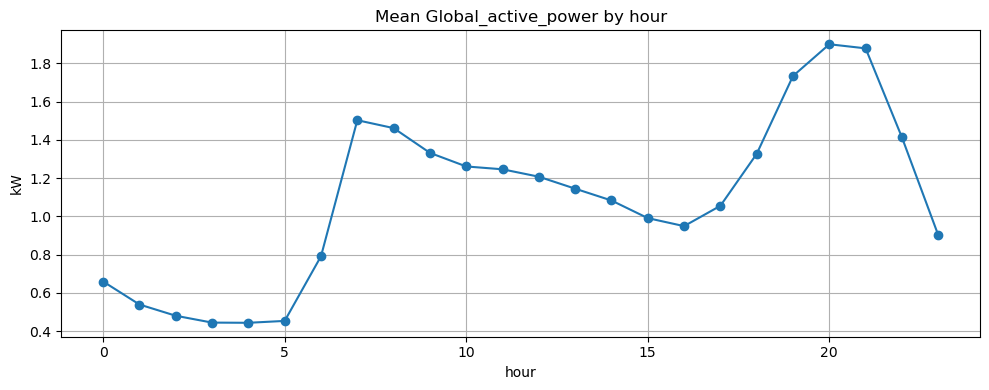

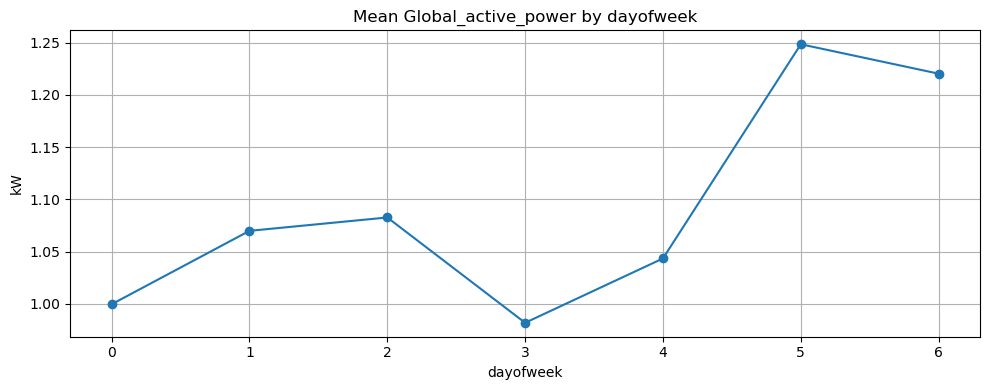

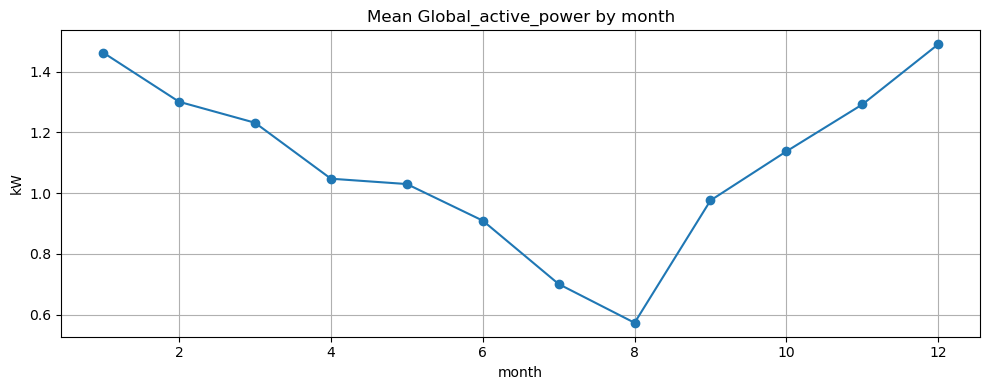

In [ ]:

plot_groupby(df, 'hour')       # by hour of day
plot_groupby(df, 'dayofweek')  # by day of week (0=Mon, 6=Sun)
plot_groupby(df, 'month')      # by month